<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_8/Day_1/Exercises%20/Exercises_XP_w8_d1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

In [2]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [4]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    tokens = nltk.word_tokenize(text.lower())

    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in string.punctuation and word not in stop_words
    ]

    return " ".join(cleaned_tokens)


### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [5]:
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [6]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    doc = nlp(text)

    entities = [(ent.text, ent.label_) for ent in doc.ents]

    return entities

print("NER Results:")
for i in range(5):
    review = raw_reviews[i]
    entities = perform_ner(review)
    print(f"Review: {review}")
    print(f"Entities: {entities}\n")


NER Results:
Review: At McDonald's the food was ok and the service was bad.
Entities: [('McDonald', 'ORG')]

Review: I would not recommend this Japanese restaurant to anyone.
Entities: [('Japanese', 'NORP')]

Review: I loved this restaurant when I traveled to Thailand last summer.
Entities: [('Thailand', 'GPE'), ('last summer', 'DATE')]

Review: The menu of Loving has a wide variety of options.
Entities: [('Loving', 'GPE')]

Review: The staff was friendly and helpful at Google's employees restaurant.
Entities: [('Google', 'ORG')]



### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [7]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    tokens = word_tokenize(text)

    tags = pos_tag(tokens)

    return tags

test_raw = raw_reviews[0]
test_clean = cleaned_reviews[0]

print(f"RAW POS: {perform_pos_tagging(test_raw)}\n")
print(f"CLEANED POS: {perform_pos_tagging(test_clean)}")


RAW POS: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]

CLEANED POS: [('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [9]:
sample_raw = raw_reviews[:2]
sample_cleaned = cleaned_reviews[:2]

print("--- NER COMPARISON ---")
print("NER on raw text")
for text in sample_raw:
    print(f"Result: {perform_ner(text)}")

print("\nNER on cleaned text")
for text in sample_cleaned:
    print(f"Result: {perform_ner(text)}")

print("\n--- POS COMPARISON ---")
print("POS tags on raw text")
for text in sample_raw:
    print(f"Result: {perform_pos_tagging(text)}")

print("\nPOS tags on cleaned text")
for text in sample_cleaned:
    print(f"Result: {perform_pos_tagging(text)}")


--- NER COMPARISON ---
NER on raw text
Result: [('McDonald', 'ORG')]
Result: [('Japanese', 'NORP')]

NER on cleaned text
Result: [("mcdonald 's food ok service", 'ORG')]
Result: [('japanese', 'NORP')]

--- POS COMPARISON ---
POS tags on raw text
Result: [('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
Result: [('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS tags on cleaned text
Result: [('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]
Result: [('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('restaurant', 'NN'), ('anyone', 'NN')]


## Exercise 2 · Plotting word embeddings




### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [10]:
from gensim.models import Word2Vec

tokenized_reviews = [review.split() for review in cleaned_reviews]

w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1
)

print(w2v_model)


Word2Vec<vocab=56, vector_size=100, alpha=0.025>


### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [11]:
vector_size = w2v_model.vector_size
vocab_size = len(w2v_model.wv)

print(f"Vector Size: {vector_size}")
print(f"Vocabulary Size: {vocab_size}")

# Interpretation:
# The Vector Size represents the number of dimensions for each word (the 'features').
# The Vocabulary Size is the total number of unique words the model has vectorized.

Vector Size: 100
Vocabulary Size: 56


### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

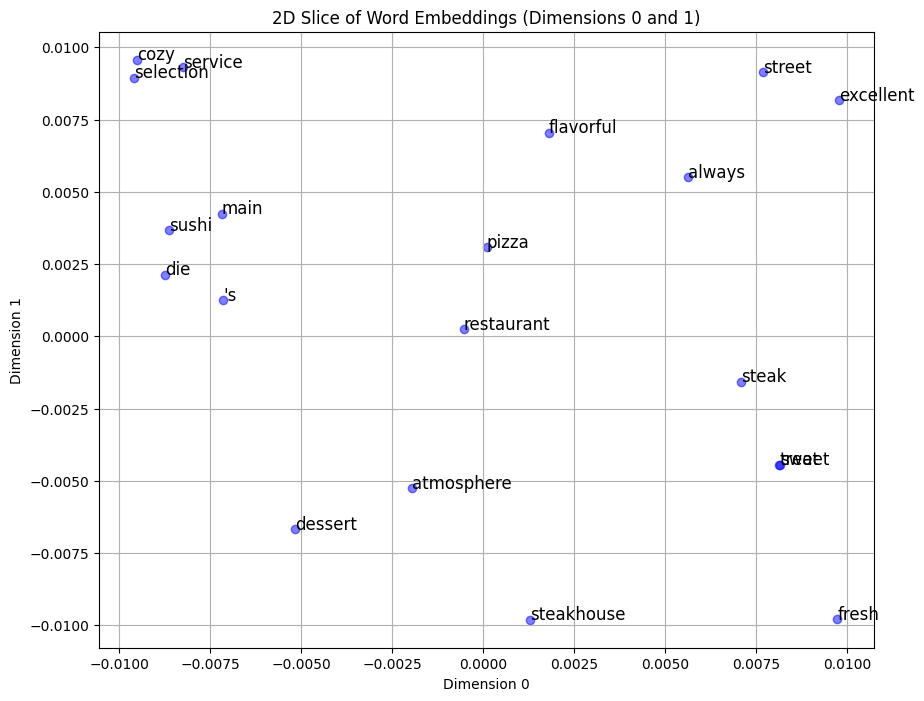

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: complete the plot_word_embeddings function
def plot_word_embeddings(model, words=None):
    if words is None:
        words = list(model.wv.index_to_key)[:20]

    word_vectors = np.array([model.wv[word] for word in words])

    x = word_vectors[:, 0]
    y = word_vectors[:, 1]

    plt.figure(figsize=(10, 8))
    plt.scatter(x, y, color='blue', alpha=0.5)

    for i, word in enumerate(words):
        plt.annotate(word, (x[i], y[i]), fontsize=12)

    plt.title("2D Slice of Word Embeddings (Dimensions 0 and 1)")
    plt.xlabel("Dimension 0")
    plt.ylabel("Dimension 1")
    plt.grid(True)
    plt.show()

plot_word_embeddings(w2v_model)


### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.

Dimensionality Reduction (PCA):

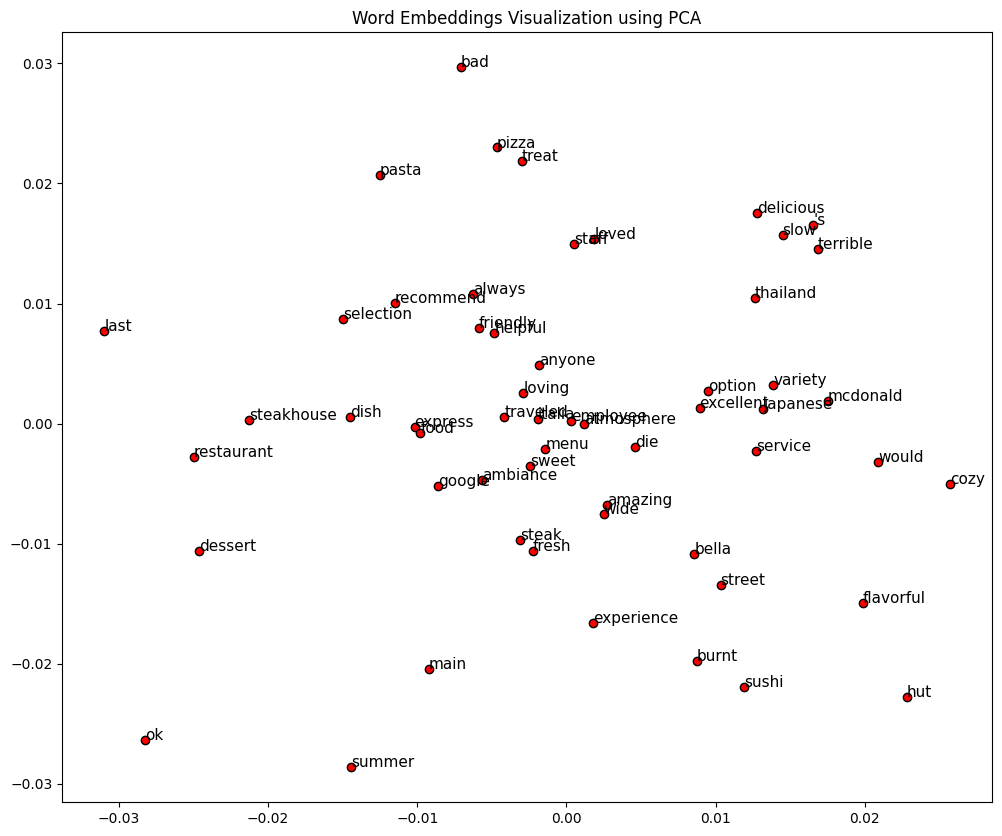

In [13]:
from sklearn.decomposition import PCA

def plot_pca_embeddings(model):
    words = list(model.wv.index_to_key)
    vectors = model.wv[words]

    pca = PCA(n_components=2)
    result = pca.fit_transform(vectors)

    plt.figure(figsize=(12, 10))
    plt.scatter(result[:, 0], result[:, 1], edgecolors='k', c='red')

    for i, word in enumerate(words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), size=11)

    plt.title("Word Embeddings Visualization using PCA")
    plt.show()

plot_pca_embeddings(w2v_model)

**Hyperparameter Tuning: Effects on Contextual Awareness**

Hyperparameter tuning serves as the primary mechanism for refining how the Word2Vec model perceives relationships between words. By increasing the window size, you allow the model to capture a broader context, which helps it identify topical similarities, such as linking specific food items to the general dining experience. Conversely, a smaller window focuses on more immediate syntactic relationships, often grouping words that function similarly in a sentence. Adjusting the vector size is equally critical; in a small dataset, reducing the dimensions can prevent the model from overfitting, helping the learned "knowledge" generalize better across the few examples provided. Choosing between Skip-gram and CBOW architectures also shifts the model's focus, with Skip-gram typically performing better on infrequent words by predicting the surrounding context from a single target word.

______

**Stemming vs. Lemmatization: Structural Integrity in NLP**

The choice between stemming and lemmatization fundamentally changes the "vocabulary" that the Word2Vec model has to work with. Lemmatization is generally preferred for professional data analysis because it uses a dictionary and morphological analysis to return words to their actual base form, such as converting "delicious" and "delicacy" appropriately while maintaining their distinct meanings. Stemming is a more aggressive, rule-based approach that chops off word endings, which can sometimes lead to "over-stemming" where different words are collapsed into the same root incorrectly. When training embeddings, lemmatization preserves more semantic nuance, allowing the Word2Vec model to create more accurate clusters because the input data remains linguistically valid rather than being reduced to truncated fragments.

_____



**Visual Analysis: What to Observe in the Embeddings**

In the resulting scatter plots, you can notice that words with similar semantic roles such as restaurant names like "McDonald's" and "Pizza Hut" or food items like "sushi" and "steak" begin to gravitate toward the same regions of the plot. If you use dimensionality reduction like PCA, these clusters should become more defined as the tool identifies the most significant axes of variance in your 100 dimensional space. Even with a limited dataset, a well tuned model will show a clear distinction between descriptive adjectives used for sentiment and the concrete nouns they describe, demonstrating that the computer has moved beyond seeing text as simple strings and is now treating it as a structured map of concepts